# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option("display.float_format", "{:.4f}".format)
# Importar librerías

### Cargar Dataset

In [2]:
df = pd.read_csv("/datasets/novaretail_comportamiento_clientes_2024.csv") 
df.info()
# Cargar el dataset y explorar datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
df.head()
# mostrar las primeras 5 filas

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0000,28565.7700,9,1,31.3600,3.9000,0,0,móvil,norte,23.2200
1,CL-100001,36.0000,29673.4400,11,3,24.6600,3.7000,0,0,tablet,sur,93.4700
2,CL-100002,46.0000,30642.9500,9,0,0.0000,2.9000,0,0,móvil,este,0.0000
3,CL-100003,56.0000,39468.6100,8,0,6.8100,3.1000,0,0,móvil,este,0.0000
4,CL-100004,35.0000,22527.8300,9,2,26.4900,2.3000,0,0,móvil,sur,33.7600


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- "edad"
- "nivel_ingreso"
- "visitas_mes"
- "compras_mes"
- "gasto_publicidad_dirigida"
- "satisfaccion"
- "ingreso_anual"


La mayoría de estas variables presentan tipos de datos adecuados.  

NO hay columna que presente valores NULOS. (Variables Numericas, Binarias y/o Categoricas) 


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
print("Novaretail", df.shape)
# Corregir el tipo de dato

Novaretail (15000, 12)


In [5]:
print(df.isna().sum())
# Cantidad de valores nulos
print(df.isna().mean())
# Proporción de valores nulos

id_cliente                   0
edad                         0
nivel_ingreso                0
visitas_mes                  0
compras_mes                  0
gasto_publicidad_dirigida    0
satisfaccion                 0
miembro_premium              0
abandono                     0
tipo_dispositivo             0
region                       0
ingreso_anual                0
dtype: int64
id_cliente                  0.0000
edad                        0.0000
nivel_ingreso               0.0000
visitas_mes                 0.0000
compras_mes                 0.0000
gasto_publicidad_dirigida   0.0000
satisfaccion                0.0000
miembro_premium             0.0000
abandono                    0.0000
tipo_dispositivo            0.0000
region                      0.0000
ingreso_anual               0.0000
dtype: float64


In [6]:
df.info()
# verificar cambios

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [7]:
df[["edad", "nivel_ingreso", "visitas_mes", "compras_mes",
       "gasto_publicidad_dirigida", "satisfaccion",
       "ingreso_anual"]].describe()
# Estadísticas descriptivas de variables numéricas

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.0000,15000.0000,15000.0000,15000.0000,15000.0000,15000.0000,15000.0000
mean,38.2624,30019.7048,10.0290,1.2065,20.1493,3.6037,36.5942
std,11.4924,9833.1663,3.1582,1.1053,10.8807,0.6853,34.4849
min,18.0000,8000.0000,1.0000,0.0000,0.0000,1.0000,0.0000
25%,30.0000,23127.0975,8.0000,0.0000,12.3100,3.1000,0.0000
50%,38.0000,30023.7450,10.0000,1.0000,19.7300,3.6000,30.7050
75%,46.0000,36768.4400,12.0000,2.0000,27.2925,4.1000,58.2200
max,75.0000,74790.8400,25.0000,8.0000,75.5100,5.0000,244.6900


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas
- NO hay valores NULOS en las columnas de variables numericas.
- Los registros presentan datos limpios.
- "edad" :  Distribucion entre 18 y 75 años. Media y mediana muy similares.
- "nivel_ingreso" : Distribucion entre 8000 y 74500 (aproximado). Media y mediana muy similares. Poner atencion en la "Desviacion Estadar".
- "visitas_mes" : Distribucion entre 1 y 25 visitas. Media y mediana iguales (redondeo).
- "compras_mes" : Distribucion entre 0 y 8 compras. Media y mediana iguales (redondeo).
- "gasto_publicidad_dirigida" : Distribucion entre 0 y 75. Media y mediana muy similares.
- "satisfaccion" : Distribucion entre 1 y 5 de calificacion. Media y mediana iguales (redondeo).
- "ingreso_anual" : Distribucion entre 0 y 245 de ingreso. Media y mediana muy similares.

#### Explorar variables binarias

In [8]:
df[["miembro_premium", "abandono"]].nunique()
# Verificar que cada columna tenga únicamente dos valores posibles

miembro_premium    2
abandono           2
dtype: int64

In [9]:
variables_bin_correcto = df[["miembro_premium", "abandono"]].isin([0, 1]).all().all()
print(variables_bin_correcto)

True


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias
- Ambas columnas NO contienen valores NULOS.
- "miembro_premium" — Contiene 2 valores.
- "abandono" — Contiene 2 valores.

#### Explorar variables categóricas

In [10]:
df[["id_cliente", "tipo_dispositivo", "region"]].nunique()
# Verificar el número de valores únicos por variable categórica

id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64

In [11]:
variables_categoricas = df["tipo_dispositivo"].isin(
    ["movil", "escritorio", "tablet"]) & df["region"].isin(
    ["este", "norte", "oeste", "sur"])
variables_categoricas_correcto = variables_categoricas.all()
print(variables_categoricas_correcto)

False


In [12]:
print(df[["tipo_dispositivo", "region"]].value_counts())
# Explorar variables categóricas y cómo se distribuyen

tipo_dispositivo  region
móvil             norte     2843
                  oeste     2489
                  sur       2483
                  este      2003
escritorio        norte     1125
                  oeste      935
                  sur        894
                  este       766
tablet            norte      427
                  oeste      386
                  sur        349
                  este       300
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- "tipo_dispositivo" : Categoria "movil" = 65.45%,
                       categoria "escritorio" = 24.80%,
                       categoria "tablet" = 9.75%.
  La categoria "movil" es la que mas genera ingresos.
- "region" : "norte" = 29.30%,
             "oeste" = 25.40%,
              "sur" = 24.84%,
              "este" = 20.46%.
  La region "norte" es la que mas genera ingresos.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

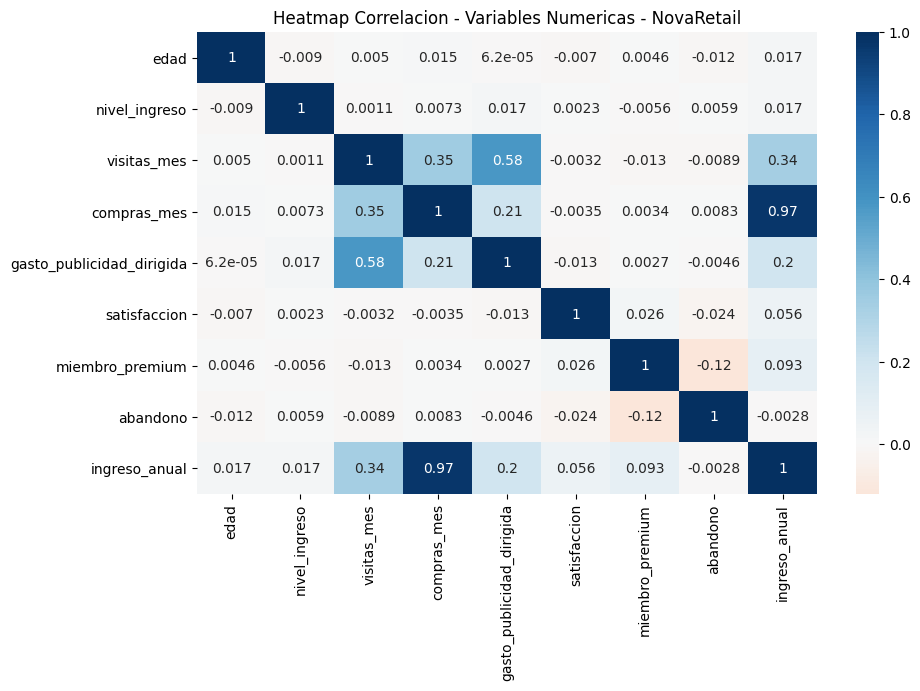

In [13]:
corr = df.corr()
corr
# Correlaciones entre variables.

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="RdBu", center=0)
plt.title("Heatmap Correlacion - Variables Numericas - NovaRetail")
plt.show()
# Visualizar la matriz de correlación para identificar relaciones

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa suceden 3 relaciones entre vriables :
    1. compras_mes vs ingreso_anual : Fuerte y positiva.
    2. gasto_publicidad_dirigida vs visitas_mes : Moderada y positiva.
    3. compras_mes vs visitas_mes : Entre sin relacion y relacion moderada, tambien, positiva.
    4. satisfaccion vs ingreso_anual : Moderada y positiva.
    5. El resto de las correlaciones muy cercanas a 0, es decir, Sin Relacion y/o Neutra.


Observaciones respecto a `ingreso_anual`  
- La variable "ingreso_anual" presenta correlacion fuerte y positiva con la variable "compras_mes". Eje del posterior analisis para validar relacion.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.
  - Las correlaciones entre las variables numericas muestran dispersiones homogeneas en general, no muestran dispersion lineal; salvo las siguientes :
        1. ingreso_anual vs compras_mes (importante analizar).
        2. compras_mes vs visitas_mes (importante analizar).
        3. gasto_publicitario_dirigido vs visitas_mes.

- **Si decides no incluirlo**:
  - Explica por qué.

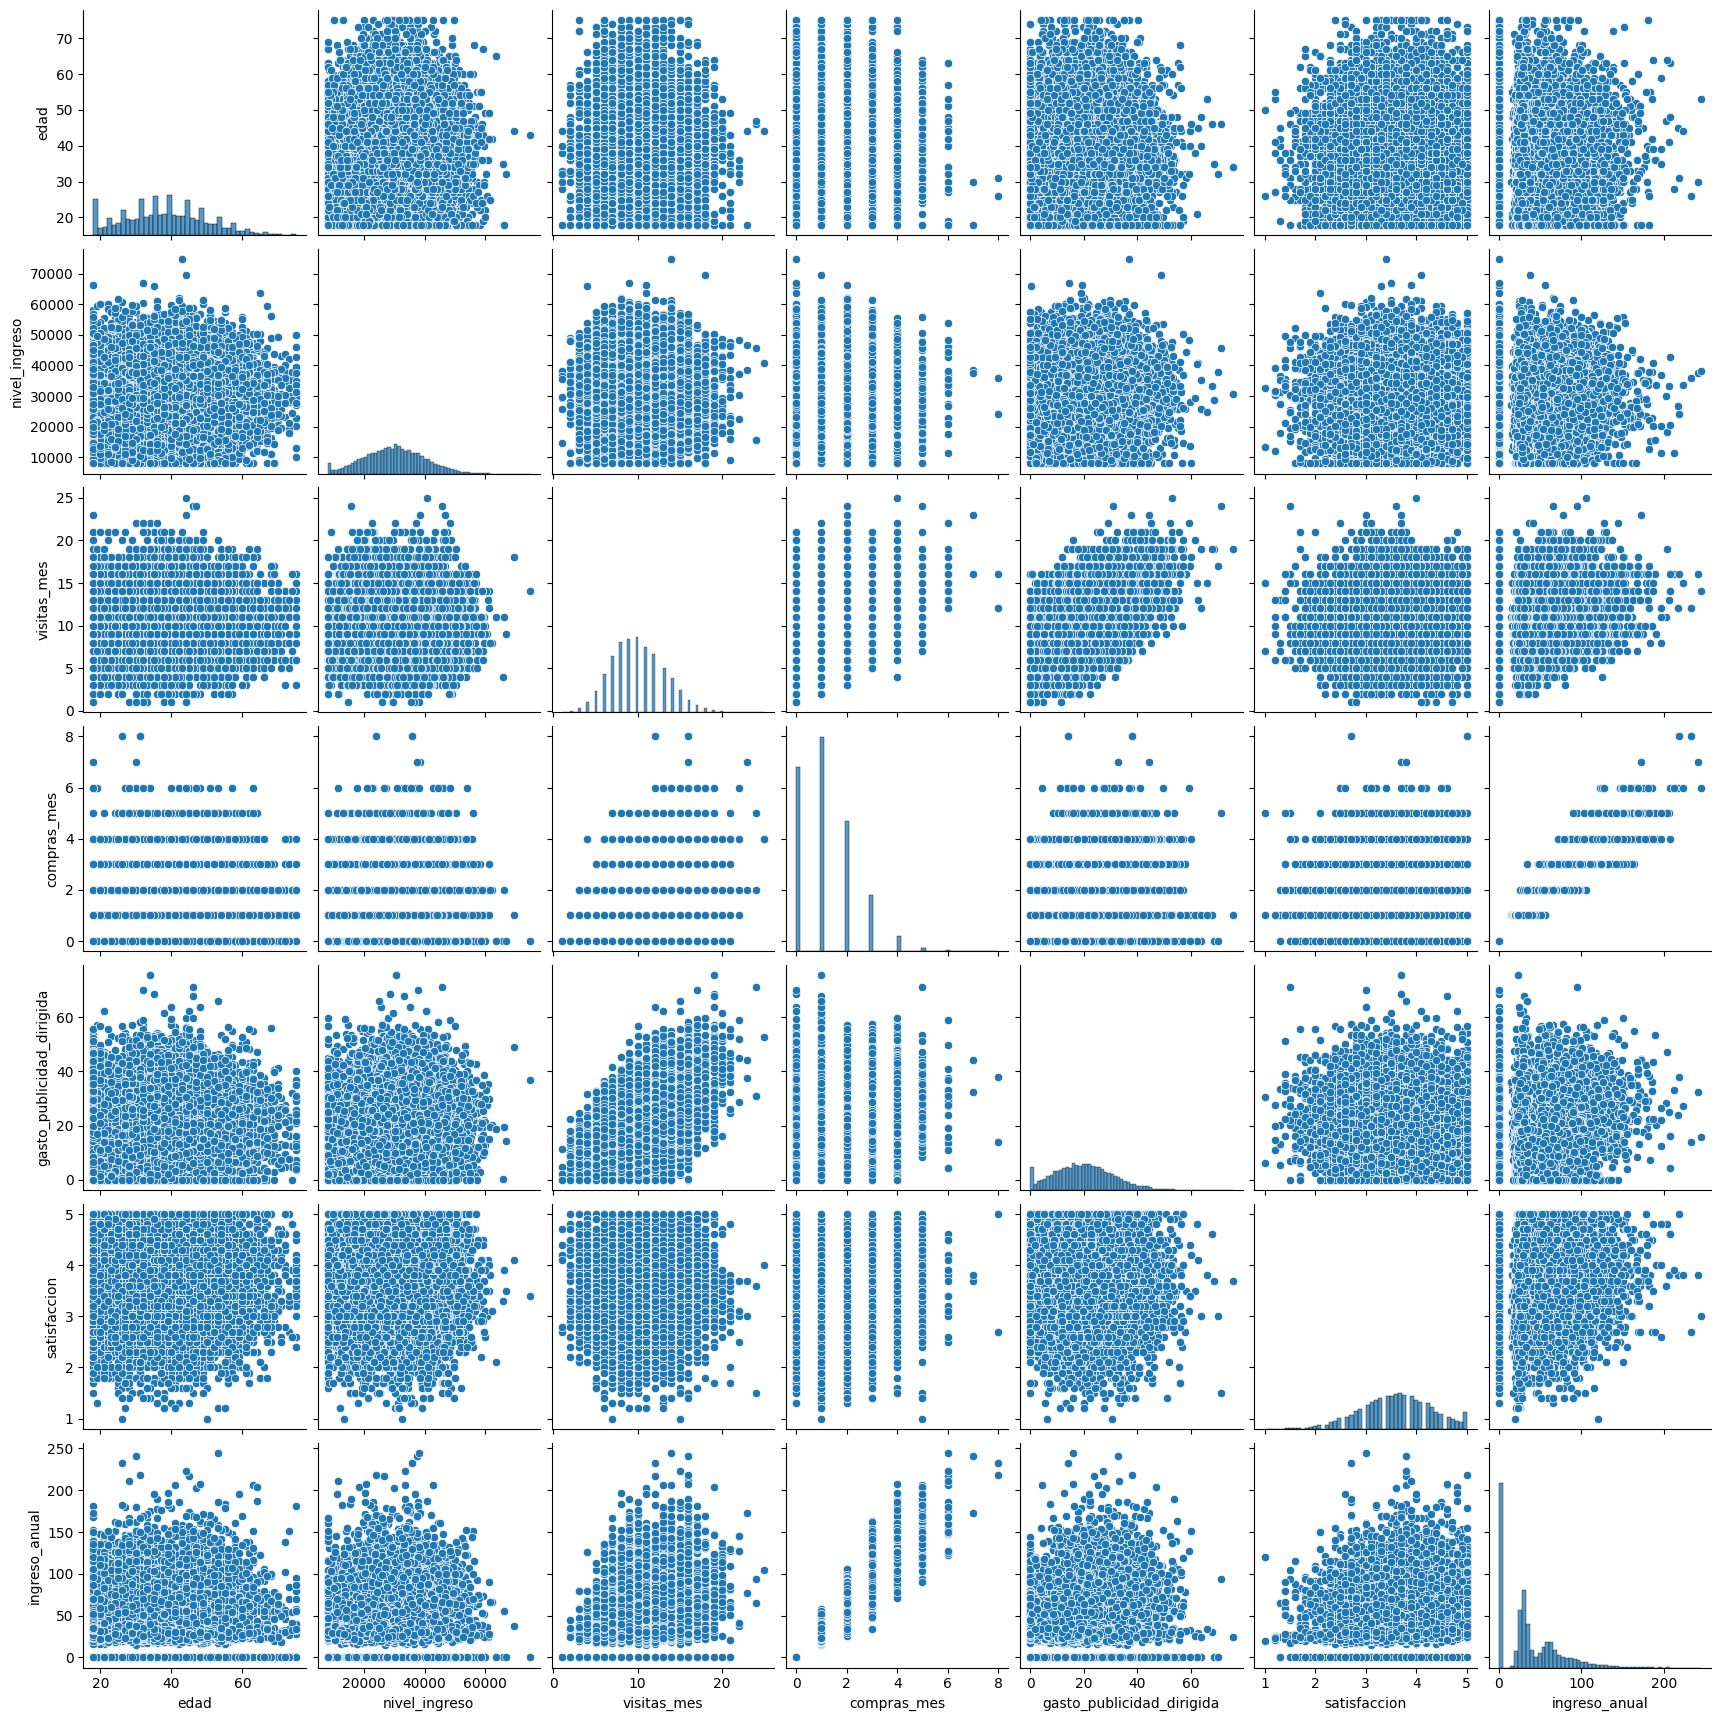

In [14]:
sns.pairplot(df[["edad", "nivel_ingreso", "visitas_mes", "compras_mes",
       "gasto_publicidad_dirigida", "satisfaccion",
       "ingreso_anual"]])
plt.show()
# Pairplot de relacion entre variables numericas.

### Scatterplot para pares clave

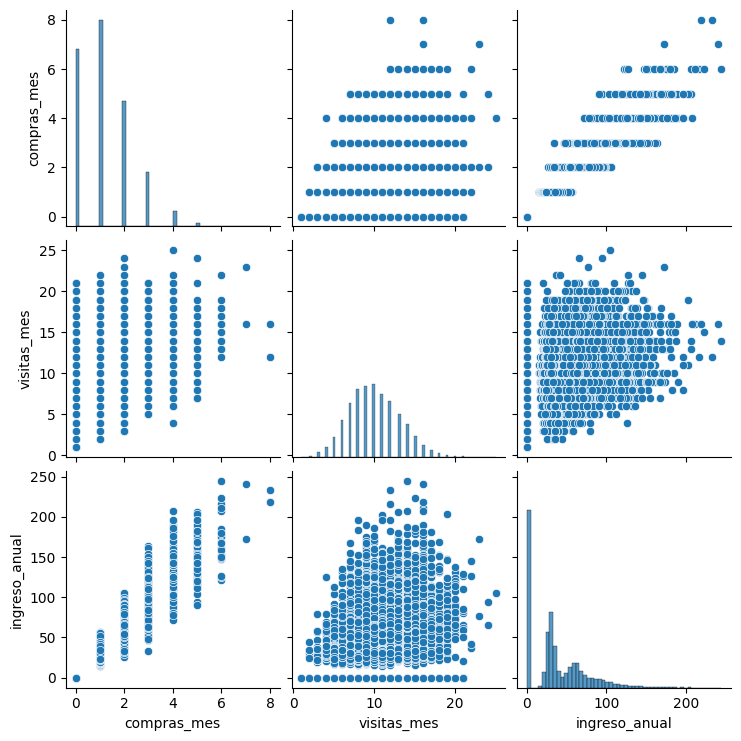

In [15]:
sns.pairplot(df[["compras_mes", "visitas_mes", "ingreso_anual"]])
plt.show()
# Visualizar pares de variables con relaciones moderadas o fuertes

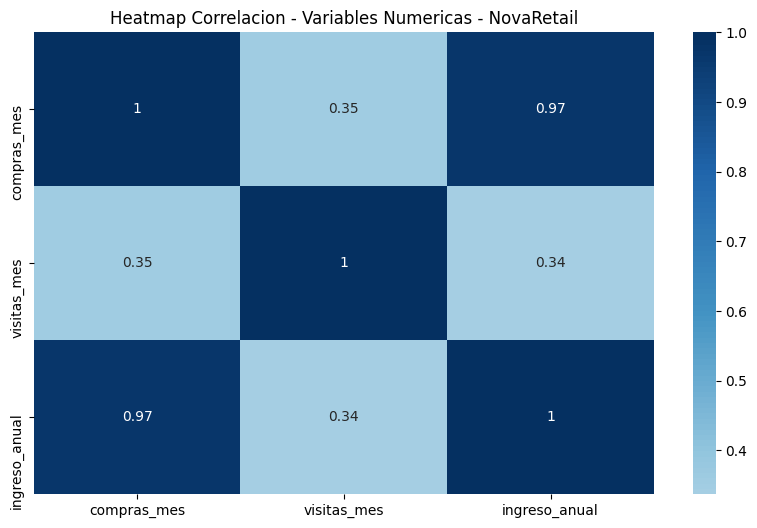

In [16]:
corr = df[["compras_mes", "visitas_mes", "ingreso_anual"]].corr()
corr
# Correlaciones entre variables.

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="RdBu", center=0)
plt.title("Heatmap Correlacion - Variables Numericas - NovaRetail")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**var1 vs var2**
- Correlacion "compras_mes" vs "visitas_mes" presenta alta dispersion con tendencia positiva moderada. No se sugiere colinealidad entre las variables.

**var1 vs var3**
- Correlacion "compras_mes" vs "ingreso_anual" presenta dispersion media a baja, por lo que interpretamos colinealidad entre las variables, con tendencia positiva fuerte.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [17]:
columnas = ["compras_mes", "visitas_mes", "ingreso_anual"]
# Defeinicion de columnas para analizar.

pearson = df[columnas].corr(method = "pearson")
pearson
# Ejecucion Metodo Pearson.

spearman = df[columnas].corr(method = "spearman")
spearman
# Ejecucion Metodo Spearman.
# Calcular correlación entre variables relevantes.

,compras_mes,visitas_mes,ingreso_anual
compras_mes,1.0000,0.3329,0.9675
visitas_mes,0.3329,1.0000,0.3210
ingreso_anual,0.9675,0.3210,1.0000


In [18]:
corr_pearson = df["compras_mes"].corr(df["ingreso_anual"], method = "pearson")
corr_spearman = df["compras_mes"].corr(df["ingreso_anual"], method = "spearman")
	# Calcular correlaciones

print("Pearson:", corr_pearson)
print("Spearman:", corr_spearman)
# Calcular correlación entre variables relevantes

Pearson: 0.9671485435708564
Spearman: 0.967482492032673


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**var1 vs var2**
- Correlación entre "compras_mes" vs "visitas_mes" es positiva y moderada a baja, esto no sugiere colinealidad.

**var2 vs var3**
- Correlación entre "visitas_mes" vs "ingreso_anual" es positiva, tambien moderada a baja, de igual forma no sugiere colinealidad entre las variables.

- Correlacion entre "compras_mes" vs "ingreso_anual" es fuerte y positiva, determinante colinealidad. Correponderia profundizar el analsis por segmentos : premium y no premium.

### Punto-biserial

In [19]:
from scipy.stats import pointbiserialr

pointbiserialr( df["miembro_premium"],  df["ingreso_anual"] )
# Calculo correlación Punto Biserial.

# Calcular correlación entre variables relevantes

SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)

In [20]:
pointbiserialr(df["abandono"], df["ingreso_anual"])
# Calculo correlacion Punto Biserial.

SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)

In [21]:
pointbiserialr(df["miembro_premium"], df["compras_mes"])
# Calculo correlación Punto Biserial.

SignificanceResult(statistic=0.003430536967706773, pvalue=0.674398174411559)

In [22]:
pointbiserialr(df["abandono"], df["compras_mes"])
# Calculo correlación Punto Biserial.

SignificanceResult(statistic=0.008290889319337781, pvalue=0.30993651903404984)

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**var1 vs var2**
- Relación entre "miembro_premium" vs "ingreso_anual" es baja, embargo positiva.

**var2 vs var3**
- Relación entre "miembro_premium" vs "compras_mes" es, todavvia mas baja, embargo tambien es positiva.

### V de Cramér

In [28]:
from scipy.stats import chi2_contingency

col1 ="region"
col2 ="tipo_dispositivo"
col3 ="miembro_premium"

def cramers_v(df, col_1, col_2):
    
    tabla = pd.crosstab(df[col_1], df[col_2])
	# tabla de contingencia

    chi2, p_value, dof, expected = chi2_contingency(tabla) 
	# calcular chi-cuadrado
    
    n = tabla.values.sum()
    coef_v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
	# calcular coeficiente V de Cramér
    
    print(f"V de Cramér ({col_1} vs {col_2}):", coef_v)
	# mostrar resultados
    
cramers_v(df, col1, col2)
cramers_v(df, col1, col3)
cramers_v(df, col2, col3)
# Ejecutar funcion

# Función para calcular V de Cramér

# Aplicar V de Cramér en variables relevantes

V de Cramér (region vs tipo_dispositivo): 0.012378338407739397
V de Cramér (region vs miembro_premium): 0.012574183027958334
V de Cramér (tipo_dispositivo vs miembro_premium): 0.01972543445542166


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér
- Relacion entre "region" vs "tipo_dispositivo" es nula, tambien es positiva.
- Relacion entre "region" vs "miembro_premium" es nula y positiva.
- Relacion entre "miembro_premium" vs "tipo_dispositivo" es nula, tambien es la mas alta de las 3 relaciones analizadas.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 —  "compras" e "ingreso_anual"

**Evidencia visual:** 
- Heatmap

**Evidencia numérica:** 
- Pearson: 0.9671485435708564
- Spearman: 0.967482492032673

**Interpretación**  
- Correlacion entre "compras_mes" vs "ingreso_anual" es fuerte y positiva, determinante colinealidad.

**No podemos afirmar**  
- NO podemos afirmar que el volumen de compras es consecuencia directa del nivel de ingresos de los clientes.

**Implicación de negocio**  
- Segmentar futuro analisis entre miembro premium y los no premium para discernir inversion en campañas de marketing.

### Hallazgo 2 — "miembro_premium" e "ingreso_anual"

**Evidencia visual:**   
- Heatmap

**Evidencia numérica:** 
- 0.93

**Interpretación**  
- Los "miembro_premium" son clientes con mayor ingreso anual.

**No podemos afirmar**  
- Que se trata de cliente con mas alto nivel de engagement.

**Implicación de negocio**  
- Reforzar el punto anterior con campañas personalizadas, si es redituable en ROI.

In [ ]:
### Hallazgo 3 — "region" y "tipo_dispositivo"

**Evidencia visual:**   
- NO generada por tratarse de variables categoricas.

**Evidencia numérica:** 
- V de Cramér (region vs tipo_dispositivo): 0.012378338407739397

**Interpretación**  
- Relacion entre variables muy cercana a la nulidad, positiva.

**No podemos afirmar**  
- Que alguna de las 4 regiones y/o alguno de los 3 tipos de dispositivos son los mayores generadores de ingresos.

**Implicación de negocio**  
- Segmentar para reforzar campañas de marketing y detectar posibles nichos de mercado.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad.
- Segmentacion no abordada en analisis.
- Hay variables que desconocemos como antiguedad de los clientes, promociones.

### **Próximos pasos** 

Probar segmentación adicional
- Por region.
- Por dispositivo.
- Miembro premium y no premium.

Probar cohortes por trimestres durante el año.
- Determinar picos de ventas.
- Definir futuras promociones.

Explorar tasa de abandono.
- De que clase de miembro se trata.
- Determinar correlacion.
- Definir campañas engagement. 1]